# Random forest

In [67]:
import pandas as pd

df = pd.read_csv("../../data/Heart.csv", index_col=0)
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        303 non-null    int64  
 1   Sex        303 non-null    int64  
 2   ChestPain  303 non-null    object 
 3   RestBP     303 non-null    int64  
 4   Chol       303 non-null    int64  
 5   Fbs        303 non-null    int64  
 6   RestECG    303 non-null    int64  
 7   MaxHR      303 non-null    int64  
 8   ExAng      303 non-null    int64  
 9   Oldpeak    303 non-null    float64
 10  Slope      303 non-null    int64  
 11  Ca         299 non-null    float64
 12  Thal       301 non-null    object 
 13  AHD        303 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 35.5+ KB


In [69]:
df_no_nulls = df.dropna()

df_no_nulls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 1 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


In [70]:
df_no_nulls["AHD"].value_counts()

AHD
No     160
Yes    137
Name: count, dtype: int64

In [71]:
df_dummies = pd.get_dummies(df_no_nulls, drop_first=True)
df_dummies.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable,AHD_Yes
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False,True
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False,False


In [72]:
X, y = df_dummies.drop("AHD_Yes", axis=1), df_dummies["AHD_Yes"]
X.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False


In [73]:
y.head()

1    False
2     True
3     True
4    False
5    False
Name: AHD_Yes, dtype: bool

In [74]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42
)

X_train.shape, X_test.shape

((198, 16), (99, 16))

## model training

- note no feature scaling for Random Forest

In [75]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

y_pred[:10]

array([False,  True, False,  True, False, False,  True,  True,  True,
       False])

In [76]:
y_test[:10].values

array([False,  True, False,  True, False, False, False, False,  True,
       False])

## Evaluation

              precision    recall  f1-score   support

       False       0.81      0.83      0.82        53
        True       0.80      0.78      0.79        46

    accuracy                           0.81        99
   macro avg       0.81      0.81      0.81        99
weighted avg       0.81      0.81      0.81        99



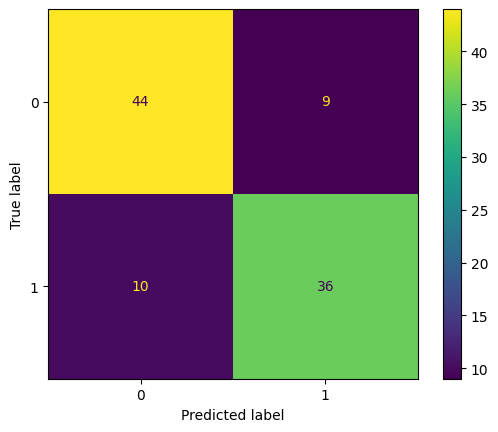

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print(classification_report(y_test, y_pred))
cm= confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot();

## Feature importance

In [78]:
model.feature_importances_ 

array([0.0946456 , 0.02831976, 0.07129319, 0.08937636, 0.01110136,
       0.01966498, 0.12499528, 0.04121852, 0.10603448, 0.0190789 ,
       0.15692303, 0.04219677, 0.01092243, 0.01710882, 0.10612102,
       0.06099949])

In [79]:
X.columns

Index(['Age', 'Sex', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR', 'ExAng',
       'Oldpeak', 'Slope', 'Ca', 'ChestPain_nonanginal',
       'ChestPain_nontypical', 'ChestPain_typical', 'Thal_normal',
       'Thal_reversable'],
      dtype='object')

In [80]:
len(X.columns), len(model.feature_importances_)

(16, 16)

In [81]:
feature_importance = pd.DataFrame([X.columns,model.feature_importances_])
feature_importance

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,0.094646,0.02832,0.071293,0.089376,0.011101,0.019665,0.124995,0.041219,0.106034,0.019079,0.156923,0.042197,0.010922,0.017109,0.106121,0.060999


In [85]:
feature_importance = feature_importance.T
feature_importance.columns = ["Feature", "Importance"]

In [86]:
feature_importance

,Feature,Importance
0,Age,0.094646
1,Sex,0.02832
2,RestBP,0.071293
3,Chol,0.089376
4,Fbs,0.011101
5,RestECG,0.019665
6,MaxHR,0.124995
7,ExAng,0.041219
8,Oldpeak,0.106034
9,Slope,0.019079


In [88]:
feature_importance = feature_importance.sort_values(by= "Importance", ascending=False)
feature_importance

,Feature,Importance
10,Ca,0.156923
6,MaxHR,0.124995
14,Thal_normal,0.106121
8,Oldpeak,0.106034
0,Age,0.094646
3,Chol,0.089376
2,RestBP,0.071293
15,Thal_reversable,0.060999
11,ChestPain_nonanginal,0.042197
7,ExAng,0.041219


In [92]:
feature_importance["Importance"].sum()

np.float64(0.9999999999999999)

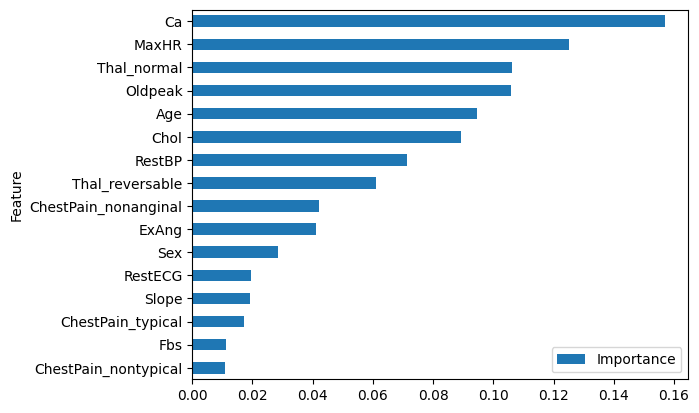

In [91]:
ax = feature_importance.plot(y = "Importance", x = "Feature", kind = "barh")
ax.invert_yaxis()